## Обучение линейного автоэнкодера ELSA (Item-Item Modeling)

In [ ]:
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, Dataset
from scipy.sparse import csr_matrix
import scipy.sparse as sp
from sklearn.preprocessing import LabelEncoder
import array

import joblib

torch.cuda.is_available()

True

In [10]:
def stream_combined_data(paths):
    for path in paths:
        with open('dataset/'+path, 'r') as f:
            movieid = None
            for i, line in enumerate(tqdm(f, desc=path)):
                line = line.strip()
                if line.endswith(':'):
                    movieid = line[:-1]
                else:
                    u, r, d = line.split(',')
                    yield (int(movieid), int(u), int(r), d)

paths = ['combined_data_1.txt','combined_data_2.txt','combined_data_3.txt','combined_data_4.txt']

In [11]:
user_encoder = joblib.load('user_encoder.joblib')
n_users = len(user_encoder.classes_)
item_encoder = joblib.load('item_encoder.joblib')
n_items = len(item_encoder.classes_)
X = sp.load_npz('X_matrix.npz')

In [12]:
# raw_user_ids = array.array('I')
# raw_item_ids = array.array('I')

# for movieid, userid, rating, _ in stream_combined_data(paths):
#     raw_user_ids.append(userid)
#     raw_item_ids.append(movieid)

# user_encoder = LabelEncoder()
# item_encoder = LabelEncoder()

# user_ids = user_encoder.fit_transform(np.array(raw_user_ids, dtype=np.int32))
# item_ids = item_encoder.fit_transform(np.array(raw_item_ids, dtype=np.int32))

# n_users = len(user_encoder.classes_)
# n_items = len(item_encoder.classes_)

# X = csr_matrix((np.ones(len(user_ids), dtype=np.float32), (user_ids, item_ids)), shape=(n_users, n_items))

# user_encoder = joblib.dump(user_encoder, 'user_encoder.joblib')
# item_encoder = joblib.dump(item_encoder, 'item_encoder.joblib')
# sp.save_npz('X_matrix.npz', X)

In [13]:
who_what_rated = pd.read_csv('who_rated_what_2006.txt', header=None, names=['user_id_orig', 'item_id_orig', 'rating'])
who_what_rated['user_id'] = user_encoder.transform(who_what_rated['user_id_orig'])
who_what_rated['item_id'] = item_encoder.transform(who_what_rated['item_id_orig'])
who_what_rated['rating'] = who_what_rated['rating'].astype(bool).astype(np.float32)
who_what_rated.head(3)

,user_id_orig,item_id_orig,rating,user_id,item_id
0,6,16983,0.0,0,16982
1,10,11888,0.0,3,11887
2,10,14584,1.0,3,14583


### ELSA

Опишем класс KDDDataset для последовательной выдачи векторов пользователей

In [14]:
class KDDDataset(Dataset):
    def __init__(self, matrix):
        self.matrix = matrix
    
    def __len__(self):
        return self.matrix.shape[0]

    def __getitem__(self, idx):
        start, end = self.matrix.indptr[idx], self.matrix.indptr[idx+1]
        indices = self.matrix.indices[start:end]
        data = self.matrix.data[start:end]
        
        row = np.zeros(self.matrix.shape[1], dtype=np.float32)
        row[indices] = data
        
        norm = np.linalg.norm(row)
        if norm > 1e-9:
            row /= norm
        return torch.from_numpy(row)

item2item подход - это подход где мы обучаем матрицу [item x item], которая восстанавливает исходную матрицу интеракций при домнажении на нее же.

Отличие ELSA от классических подходов (SLIM/EASE) заключается в том, что мы раскладываем обучаемую матрицу на две A и B.

In [15]:
class ELSA(nn.Module):
    def __init__(self, n_items, n_factors=64):
        super().__init__()
        self.A = nn.Linear(n_items, n_factors, bias=False)
        self.B = nn.Linear(n_factors, n_items, bias=False)
    
    def forward(self, x):
        return self.B(self.A(x))

In [16]:
device = torch.device("cuda")
model = ELSA(n_items).to(device)
dataset = KDDDataset(X)
loader = DataLoader(dataset, batch_size=2048, shuffle=True, num_workers=4)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)


for epoch in range(12):
    break # Если могу скачать модель, то не нужно обучать
    model.train()
    total_loss = 0
    for x in tqdm(loader):
        x = x.to(device)
        optimizer.zero_grad()
        
        y_pred = model(x)
        
        bce_loss = nn.MSELoss(reduction='sum')(y_pred, x)
        
        # Считаем diag(W) = diag(B_weight @ A_weight) без вычисления всей матрицы
        diag_w = (model.B.weight * model.A.weight.T).sum(dim=1)
        diag_penalty = torch.sum(diag_w**2)
        
        loss = (bce_loss + 0.5 * diag_penalty) / x.shape[0]
        
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            model.A.weight.clamp_(min=0)
            model.B.weight.clamp_(min=0)
            
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1} | Loss: {total_loss/len(loader):.5f}")

# torch.save(model.state_dict(), 'elsa_model.pth')
model.load_state_dict(torch.load('elsa_model.pth', map_location=device))

100%|██████████| 235/235 [00:20<00:00, 11.25it/s]


Epoch 1 | Loss: 1.43868


100%|██████████| 235/235 [00:18<00:00, 12.58it/s]


Epoch 2 | Loss: 0.87650


100%|██████████| 235/235 [00:18<00:00, 12.73it/s]


...

Epoch 10 | Loss: 0.79684


100%|██████████| 235/235 [00:18<00:00, 12.55it/s]


Epoch 11 | Loss: 0.79215


100%|██████████| 235/235 [00:18<00:00, 12.49it/s]


Epoch 12 | Loss: 0.78447


In [17]:
model.eval()

unique_user_ids = who_what_rated['user_id'].unique()
batch_size = 2048
user_to_preds = {}

with torch.no_grad():
    for i in range(0, len(unique_user_ids), batch_size):
        batch_u = unique_user_ids[i:i + batch_size]
        
        x_batch = torch.stack([dataset[u] for u in batch_u]).to(device)
        
        preds = model(x_batch).cpu().numpy()
        
        for j, u_id in enumerate(batch_u):
            user_to_preds[u_id] = preds[j]

u_ids = who_what_rated['user_id'].values
i_ids = who_what_rated['item_id'].values

who_what_rated['y_pred'] = [user_to_preds[u][i] for u, i in zip(u_ids, i_ids)]

In [18]:
who_what_rated['squared_error'] = (who_what_rated['rating'] - who_what_rated['y_pred']) ** 2
rmse = np.sqrt(who_what_rated['squared_error'].mean())

print(f"ELSA RMSE: {rmse:.4}")

ELSA RMSE: 0.2763


Посмотрим на предсказания ELSA, отсортируем test по величине предсказания.

In [19]:
who_what_rated[['user_id', 'item_id', 'rating', 'y_pred']].sort_values('y_pred', ascending=False).head(10)

,user_id,item_id,rating,y_pred
27710,132857,14312,1.0,0.129831
65377,312922,13049,0.0,0.128860
38546,184717,7233,0.0,0.120051
4882,24368,7233,0.0,0.112052
20496,98796,14366,0.0,0.102564
98463,473199,7233,0.0,0.097509
49173,236245,13650,0.0,0.094972
87088,418577,12910,0.0,0.091748
97381,468067,13650,1.0,0.091429
22996,110569,14312,0.0,0.087866


Также посмотрим на ROC и Pr кривые:

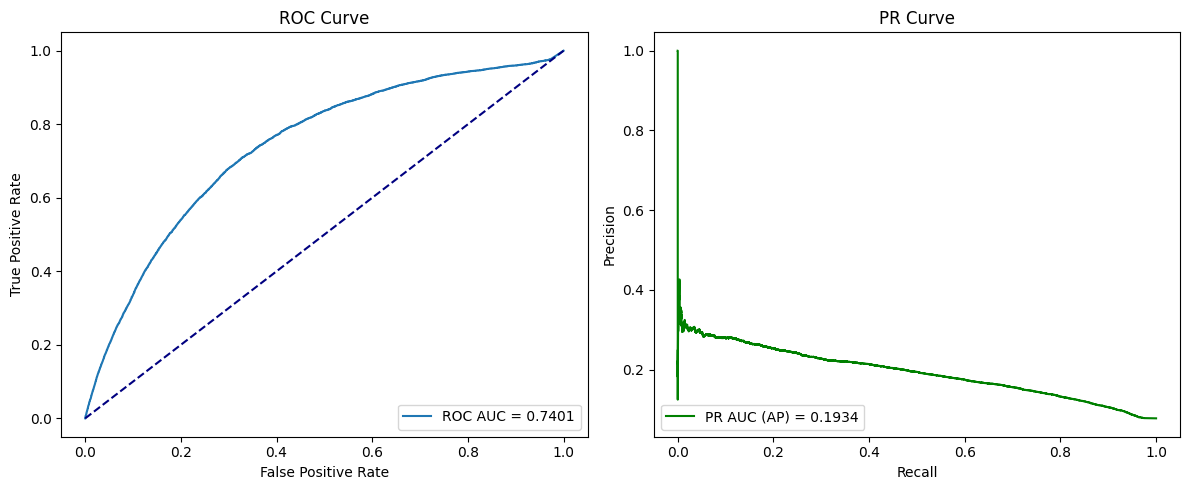

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

y_true = who_what_rated['rating'].values
y_scores = who_what_rated['y_pred'].values

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_true, y_scores)
pr_auc = average_precision_score(y_true, y_scores)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
ax1.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
ax1.plot([0, 1], [0, 1], color='navy', linestyle='--')
ax1.set_title('ROC Curve')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc="lower right")

# PR Curve
ax2.plot(recall, precision, color='green', label=f'PR AUC (AP) = {pr_auc:.4f}')
ax2.set_title('PR Curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

RMSE : 0.2763